# AI Inversion

This notebook is now the analysis hub for A1. The SOC and NAICS crosswalk construction lives upstream in `soc_crosswalk_rebuild.ipynb` and `naics_crosswalk_rebuild.ipynb`; this file starts from those cleaned outputs and the governed metro employment surfaces.

## Notebook Structure

- Load the cleaned SOC and NAICS Felten join tables.
- Load the governed CBSA surfaces we need for analysis.
- Build metro-level SOC and NAICS exposure tables.
- Start Part 1 of the analysis plan with the descriptive baseline.

Important source note: `gold` gives us the metro-wide comparison panel we will use later for industry mix, education, and broad occupation context. The detailed SOC and 4-digit NAICS rows still come from the governed BLS layers because Gold does not currently ship detailed code-level surfaces at the grain this analysis needs.

In [33]:
from __future__ import annotations

# Core notebook setup. Keep all paths repo-relative so this notebook can run cleanly
# across local environments without hardcoded machine-specific references.
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "foundations").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "foundations").exists():
            REPO_ROOT = parent
            break

ANALYSIS_ROOT = REPO_ROOT / "metro-deep-dive" / "analysis_program" / "01_ai_inversion"
OUTPUT_ROOT = ANALYSIS_ROOT / "outputs"
DB_PATH = REPO_ROOT / "foundations" / "etl" / "data" / "duckdb" / "patterns_in_place.duckdb"

SOC_CROSSWALK_PATH = OUTPUT_ROOT / "soc_felten_join_reference.csv"
NAICS_CROSSWALK_PATH = OUTPUT_ROOT / "naics_felten_join_reference.csv"

RICHMOND_CBSA_CODE = "40060"

display(pd.DataFrame([
    {"path": "DuckDB", "value": DB_PATH.relative_to(REPO_ROOT)},
    {"path": "Analysis root", "value": ANALYSIS_ROOT.relative_to(REPO_ROOT)},
    {"path": "SOC crosswalk", "value": SOC_CROSSWALK_PATH.relative_to(REPO_ROOT)},
    {"path": "NAICS crosswalk", "value": NAICS_CROSSWALK_PATH.relative_to(REPO_ROOT)},
]))

,path,value
0,DuckDB,foundations/etl/data/duckdb/patterns_in_place....
1,Analysis root,metro-deep-dive/analysis_program/01_ai_inversion
2,SOC crosswalk,metro-deep-dive/analysis_program/01_ai_inversi...
3,NAICS crosswalk,metro-deep-dive/analysis_program/01_ai_inversi...


## 1. Load The Cleaned Felten Crosswalks

These are the canonical downstream join tables produced by the rebuild notebooks. The analysis notebook should treat them as fixed inputs rather than rebuilding the vintage reconciliation logic here.

In [34]:
# Read the cleaned SOC and NAICS Felten join tables that we will use throughout the analysis.
# We coerce the score fields to numeric immediately so downstream exposure math is explicit.
soc_felten_join_reference = pd.read_csv(SOC_CROSSWALK_PATH, dtype=str)
soc_felten_join_reference["felten_score"] = pd.to_numeric(soc_felten_join_reference["felten_score"], errors="coerce")

naics_felten_join_reference = pd.read_csv(NAICS_CROSSWALK_PATH, dtype=str)
naics_felten_join_reference["felten_score"] = pd.to_numeric(naics_felten_join_reference["felten_score"], errors="coerce")

crosswalk_summary = pd.DataFrame([
    {
        "surface": "SOC",
        "rows": len(soc_felten_join_reference),
        "rows_with_score": int(soc_felten_join_reference["felten_score"].notna().sum()),
        "missing_scores": int(soc_felten_join_reference["felten_score"].isna().sum()),
    },
    {
        "surface": "NAICS",
        "rows": len(naics_felten_join_reference),
        "rows_with_score": int(naics_felten_join_reference["felten_score"].notna().sum()),
        "missing_scores": int(naics_felten_join_reference["felten_score"].isna().sum()),
    },
])

display(crosswalk_summary)
display(soc_felten_join_reference.head(10))
display(naics_felten_join_reference.head(10))

,surface,rows,rows_with_score,missing_scores
0,SOC,824,788,36
1,NAICS,332,327,5


,our_soc_code,our_name,felten_soc_code,felten_soc_name,felten_soc_code_2010_final,felten_soc_title,felten_score,match_basis,manual_notes,review_source
0,11-1011,Chief Executives,11-1011,Chief Executives,11-1011,Chief Executives,1.334246,raw_crosswalk_single_match,NaN,notebook_raw_soc_bridge
1,11-1021,General and Operations Managers,11-1021,General and Operations Managers,11-1021,General and Operations Managers,0.574877,raw_crosswalk_single_match,NaN,notebook_raw_soc_bridge
2,11-2011,Advertising and Promotions Managers,11-2011,Advertising and Promotions Managers,11-2011,Advertising and Promotions Managers,1.294387,raw_crosswalk_single_match,NaN,notebook_raw_soc_bridge
3,11-2021,Marketing Managers,11-2021,Marketing Managers,11-2021,Marketing Managers,1.315032,raw_crosswalk_single_match,NaN,notebook_raw_soc_bridge
4,11-2022,Sales Managers,11-2022,Sales Managers,11-2022,Sales Managers,1.266280,raw_crosswalk_single_match,NaN,notebook_raw_soc_bridge
5,11-2032,Public Relations Managers,11-2031,Public Relations Managers,11-2031,Public Relations Managers,1.293689,accepted_suggested_join,Same SOC major group with moderate title align...,recommended_felten_soc_overrides_initial
6,11-2033,Fundraising Managers,11-2031,Public Relations Managers,11-2031,Public Relations Managers,1.293689,accepted_suggested_join,Same SOC major group with moderate title align...,recommended_felten_soc_overrides_initial
7,11-3012,Administrative Services Managers,11-3011,Administrative Services Managers,11-3011,Administrative Services Managers,0.739828,accepted_suggested_join,Same SOC major group with strong title alignment.,recommended_felten_soc_overrides_initial
8,11-3013,Facilities Managers,11-3011,Administrative Services Managers,11-3011,Administrative Services Managers,0.739828,accepted_suggested_join,Same SOC major group with moderate title align...,recommended_felten_soc_overrides_initial
9,11-3021,Computer and Information Systems Managers,11-3021,Computer and Information Systems Managers,11-3021,Computer and Information Systems Managers,1.059853,raw_crosswalk_single_match,NaN,notebook_raw_soc_bridge


,our_naics_code,our_name,felten_naics_code,felten_naics_name,felten_score,match_basis,manual_notes,review_source
0,1111,Oilseed and grain farming,1151,Support Activities for Crop Production,-2.165304,manual_override,Notebook lock: use crop-support activities as ...,notebook_locked_naics_manual_review
1,1112,Vegetable and melon farming,1151,Support Activities for Crop Production,-2.165304,manual_override,Notebook lock: use crop-support activities as ...,notebook_locked_naics_manual_review
2,1113,Fruit and tree nut farming,1151,Support Activities for Crop Production,-2.165304,manual_override,Notebook lock: use crop-support activities as ...,notebook_locked_naics_manual_review
3,1114,Greenhouse and nursery production,1151,Support Activities for Crop Production,-2.165304,manual_override,Notebook lock: use crop-support activities as ...,notebook_locked_naics_manual_review
4,1119,Other crop farming,1151,Support Activities for Crop Production,-2.165304,manual_override,Notebook lock: use crop-support activities as ...,notebook_locked_naics_manual_review
5,1121,Cattle ranching and farming,1152,Support Activities for Animal Production,-1.149307,manual_override,Notebook lock: use animal-support activities a...,notebook_locked_naics_manual_review
6,1122,Hog and pig farming,1152,Support Activities for Animal Production,-1.149307,manual_override,Notebook lock: use animal-support activities a...,notebook_locked_naics_manual_review
7,1123,Poultry and egg production,1152,Support Activities for Animal Production,-1.149307,manual_override,Notebook lock: use animal-support activities a...,notebook_locked_naics_manual_review
8,1124,Sheep and goat farming,1152,Support Activities for Animal Production,-1.149307,manual_override,Notebook lock: use animal-support activities a...,notebook_locked_naics_manual_review
9,1125,Aquaculture,1152,Support Activities for Animal Production,-1.149307,manual_override,Notebook lock: use animal-support activities a...,notebook_locked_naics_manual_review


## 2. Load The Governed Metro Surfaces

This block does two things.

First, it loads the CBSA-level comparison panel from Gold that we will use later for the hypotheses in `analysis_program.md`. Second, it loads the detailed SOC and 4-digit NAICS employment surfaces that the exposure math actually runs on.

In [35]:
# Gold holds the wide comparison panel for later analysis. The detailed code-level exposure work
# still has to come from the governed BLS layers because Gold is intentionally rolled up.
industry_wide_sql = """
SELECT *
FROM gold.economics_industry_wide
WHERE geo_level = 'cbsa'
ORDER BY geo_id, year
"""

occupation_wide_sql = """
SELECT *
FROM gold.economics_occupation_wide
WHERE geo_level = 'cbsa'
ORDER BY geo_id, year
"""

population_sql = """
SELECT *
FROM gold.population_demographics
WHERE geo_level = 'cbsa'
ORDER BY geo_id, year
"""

soc_cbsa_sql = """
WITH cbsa_totals AS (
    SELECT
        geo_id,
        geo_name,
        year,
        employment AS cbsa_total_employment
    FROM silver.bls_oews
    WHERE geo_level = 'cbsa'
      AND is_total_occupation
), detailed_rows AS (
    SELECT
        geo_id,
        geo_name,
        year,
        soc_code,
        soc_title,
        occupation_bucket,
        is_stem,
        employment,
        annual_mean_wage,
        location_quotient
    FROM silver.bls_oews
    WHERE geo_level = 'cbsa'
      AND o_group = 'detailed'
)
SELECT
    d.geo_id AS cbsa_code,
    d.geo_name AS cbsa_name,
    d.year,
    d.soc_code,
    d.soc_title,
    d.occupation_bucket,
    d.is_stem,
    d.employment,
    d.annual_mean_wage,
    d.location_quotient,
    t.cbsa_total_employment
FROM detailed_rows d
LEFT JOIN cbsa_totals t
  ON d.geo_id = t.geo_id
 AND d.year = t.year
ORDER BY cbsa_code, year, employment DESC, soc_code
"""

naics_cbsa_sql = """
WITH detailed_rows AS (
    SELECT
        x.cbsa_code AS cbsa_code,
        x.cbsa_name AS cbsa_name,
        c.period AS year,
        c.industry_code AS naics_code,
        any_value(c.industry_title) AS naics_title,
        SUM(c.annual_avg_emplvl) AS employment
    FROM staging.bls_qcew_county c
    INNER JOIN silver.xwalk_cbsa_county x
        ON c.county_fips_code = x.county_fips
    INNER JOIN silver.bls_qcew_industry_map m
        ON c.industry_code = m.industry_code
    WHERE c.own_code = '5'
      AND m.code_type = 'naics_industry_group'
    GROUP BY 1, 2, 3, 4
)
SELECT
    cbsa_code,
    cbsa_name,
    year,
    naics_code,
    naics_title,
    employment,
    SUM(employment) OVER (PARTITION BY cbsa_code, year) AS cbsa_total_employment
FROM detailed_rows
ORDER BY cbsa_code, year, employment DESC, naics_code
"""

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    industry_wide_cbsa = con.execute(industry_wide_sql).fetchdf()
    occupation_wide_cbsa = con.execute(occupation_wide_sql).fetchdf()
    population_cbsa = con.execute(population_sql).fetchdf()
    soc_cbsa_base = con.execute(soc_cbsa_sql).fetchdf()
    naics_cbsa_base = con.execute(naics_cbsa_sql).fetchdf()

for frame_name, numeric_cols in {
    "soc_cbsa_base": ["employment", "annual_mean_wage", "location_quotient", "cbsa_total_employment"],
    "naics_cbsa_base": ["employment", "cbsa_total_employment"],
}.items():
    frame = locals()[frame_name]
    for col in numeric_cols:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

surface_summary = pd.DataFrame([
    {
        "surface": "gold.economics_industry_wide",
        "rows": len(industry_wide_cbsa),
        "cbsas": industry_wide_cbsa["geo_id"].nunique(),
        "year_min": int(industry_wide_cbsa["year"].min()),
        "year_max": int(industry_wide_cbsa["year"].max()),
    },
    {
        "surface": "gold.economics_occupation_wide",
        "rows": len(occupation_wide_cbsa),
        "cbsas": occupation_wide_cbsa["geo_id"].nunique(),
        "year_min": int(occupation_wide_cbsa["year"].min()),
        "year_max": int(occupation_wide_cbsa["year"].max()),
    },
    {
        "surface": "gold.population_demographics",
        "rows": len(population_cbsa),
        "cbsas": population_cbsa["geo_id"].nunique(),
        "year_min": int(population_cbsa["year"].min()),
        "year_max": int(population_cbsa["year"].max()),
    },
    {
        "surface": "Detailed SOC CBSA rows",
        "rows": len(soc_cbsa_base),
        "cbsas": soc_cbsa_base["cbsa_code"].nunique(),
        "year_min": int(soc_cbsa_base["year"].min()),
        "year_max": int(soc_cbsa_base["year"].max()),
    },
    {
        "surface": "Detailed NAICS CBSA rows",
        "rows": len(naics_cbsa_base),
        "cbsas": naics_cbsa_base["cbsa_code"].nunique(),
        "year_min": int(naics_cbsa_base["year"].min()),
        "year_max": int(naics_cbsa_base["year"].max()),
    },
])

display(surface_summary)
display(soc_cbsa_base.head(10))
display(naics_cbsa_base.head(10))

,surface,rows,cbsas,year_min,year_max
0,gold.economics_industry_wide,12085,935,2012,2024
1,gold.economics_occupation_wide,393,393,2025,2025
2,gold.population_demographics,12085,935,2012,2024
3,Detailed SOC CBSA rows,141015,393,2025,2025
4,Detailed NAICS CBSA rows,4108350,935,2010,2024


,cbsa_code,cbsa_name,year,soc_code,soc_title,occupation_bucket,is_stem,employment,annual_mean_wage,location_quotient,cbsa_total_employment
0,10180,"Abilene, TX",2025,35-3023,Fast Food and Counter Workers,service,False,2930.0,26070.0,1.57,75070.0
1,10180,"Abilene, TX",2025,43-4051,Customer Service Representatives,other,False,2550.0,39590.0,2.03,75070.0
2,10180,"Abilene, TX",2025,11-1021,General and Operations Managers,management_professional,False,2120.0,113630.0,1.25,75070.0
3,10180,"Abilene, TX",2025,41-2031,Retail Salespersons,other,False,2000.0,33180.0,1.06,75070.0
4,10180,"Abilene, TX",2025,31-1120,Home Health and Personal Care Aides,service,False,1820.0,25690.0,0.88,75070.0
5,10180,"Abilene, TX",2025,41-2011,Cashiers,other,False,1780.0,27830.0,1.19,75070.0
6,10180,"Abilene, TX",2025,29-1141,Registered Nurses,management_professional,False,1680.0,85170.0,1.03,75070.0
7,10180,"Abilene, TX",2025,53-7065,Stockers and Order Fillers,production_transportation,False,1380.0,34820.0,1.01,75070.0
8,10180,"Abilene, TX",2025,43-9061,"Office Clerks, General",other,False,1110.0,38890.0,0.93,75070.0
9,10180,"Abilene, TX",2025,53-3032,Heavy and Tractor-Trailer Truck Drivers,production_transportation,False,1090.0,56610.0,1.09,75070.0


,cbsa_code,cbsa_name,year,naics_code,naics_title,employment,cbsa_total_employment
0,10100,"Aberdeen, SD",2010,7221,Full-service restaurants,160490.0,3383827.0
1,10100,"Aberdeen, SD",2010,7222,Limited-service eating places,145418.0,3383827.0
2,10100,"Aberdeen, SD",2010,5613,Employment services,117415.0,3383827.0
3,10100,"Aberdeen, SD",2010,4451,Grocery stores,99324.0,3383827.0
4,10100,"Aberdeen, SD",2010,6221,General medical and surgical hospitals,93492.0,3383827.0
5,10100,"Aberdeen, SD",2010,6211,Offices of physicians,86466.0,3383827.0
6,10100,"Aberdeen, SD",2010,5617,Services to buildings and dwellings,68854.0,3383827.0
7,10100,"Aberdeen, SD",2010,5221,Depository credit intermediation,60310.0,3383827.0
8,10100,"Aberdeen, SD",2010,2382,Building equipment contractors,59952.0,3383827.0
9,10100,"Aberdeen, SD",2010,5511,Management of companies and enterprises,52714.0,3383827.0


## 3. Build Metro Exposure Tables

This is the first real analytical step. We join the cleaned Felten scores onto the governed metro code surfaces and compute the employment-weighted exposure measures we will use throughout the rest of the notebook.

In [36]:
# Join the cleaned Felten scores onto the detailed SOC and NAICS CBSA surfaces, then compute
# the metro-level exposure measures. We keep coverage stats alongside the index because low
# coverage metros should be flagged before we interpret any ranking or comparison.
soc_cbsa_scored = soc_cbsa_base.merge(
    soc_felten_join_reference[["our_soc_code", "felten_score"]].rename(columns={"our_soc_code": "soc_code"}),
    on="soc_code",
    how="left",
    validate="many_to_one",
)
soc_cbsa_scored["matched_flag"] = soc_cbsa_scored["felten_score"].notna()

# The SOC inversion measure only lives on the published detailed-SOC surface. That means the
# primary employment denominator for both `E_m` and the scored coverage stats has to be the sum
# of detailed rows, not the OEWS all-occupation total. We keep the detailed-vs-total gap as a
# separate QA field because it reflects OEWS publication coverage rather than Felten matching.
soc_cbsa_scored["detailed_employment_share"] = soc_cbsa_scored.groupby(["cbsa_code", "year"])["employment"].transform(
    lambda values: values / values.sum()
)
soc_cbsa_scored["exposure_contribution"] = soc_cbsa_scored["detailed_employment_share"] * soc_cbsa_scored["felten_score"]
soc_cbsa_scored["wage_bill"] = soc_cbsa_scored["employment"] * soc_cbsa_scored["annual_mean_wage"]
soc_cbsa_scored["matched_wage_bill"] = np.where(soc_cbsa_scored["matched_flag"], soc_cbsa_scored["wage_bill"], np.nan)
soc_cbsa_scored["wage_exposure_component"] = np.where(
    soc_cbsa_scored["matched_flag"],
    soc_cbsa_scored["wage_bill"] * soc_cbsa_scored["felten_score"],
    np.nan,
)

soc_metro_exposure = (
    soc_cbsa_scored.groupby(["cbsa_code", "cbsa_name", "year"], as_index=False)
    .agg(
        cbsa_total_employment=("cbsa_total_employment", "max"),
        cbsa_detailed_employment=("employment", "sum"),
        matched_employment=("employment", lambda values: float(values[soc_cbsa_scored.loc[values.index, "matched_flag"]].sum())),
        total_soc_rows=("soc_code", "count"),
        matched_soc_rows=("matched_flag", "sum"),
        e_m=("exposure_contribution", "sum"),
        cbsa_total_payroll=("wage_bill", "sum"),
        matched_payroll=("matched_wage_bill", "sum"),
        w_m_local_numerator=("wage_exposure_component", "sum"),
    )
)
soc_metro_exposure["coverage_share"] = soc_metro_exposure["matched_employment"] / soc_metro_exposure["cbsa_detailed_employment"]
soc_metro_exposure["detailed_share_of_total_oe_ws"] = soc_metro_exposure["cbsa_detailed_employment"] / soc_metro_exposure["cbsa_total_employment"]
soc_metro_exposure["payroll_coverage_share"] = soc_metro_exposure["matched_payroll"] / soc_metro_exposure["cbsa_total_payroll"]
soc_metro_exposure["w_m_local"] = soc_metro_exposure["w_m_local_numerator"] / soc_metro_exposure["matched_payroll"]

naics_cbsa_scored = naics_cbsa_base.merge(
    naics_felten_join_reference[["our_naics_code", "felten_score"]].rename(columns={"our_naics_code": "naics_code"}),
    on="naics_code",
    how="left",
    validate="many_to_one",
)
naics_cbsa_scored["matched_flag"] = naics_cbsa_scored["felten_score"].notna()
naics_cbsa_scored["employment_share_total"] = naics_cbsa_scored["employment"] / naics_cbsa_scored["cbsa_total_employment"]
naics_cbsa_scored["exposure_contribution"] = naics_cbsa_scored["employment_share_total"] * naics_cbsa_scored["felten_score"]

naics_metro_exposure = (
    naics_cbsa_scored.groupby(["cbsa_code", "cbsa_name", "year"], as_index=False)
    .agg(
        cbsa_total_employment=("cbsa_total_employment", "max"),
        matched_employment=("employment", lambda values: float(values[naics_cbsa_scored.loc[values.index, "matched_flag"]].sum())),
        total_naics_rows=("naics_code", "count"),
        matched_naics_rows=("matched_flag", "sum"),
        naics_exposure_index=("exposure_contribution", "sum"),
    )
)
naics_metro_exposure["coverage_share"] = naics_metro_exposure["matched_employment"] / naics_metro_exposure["cbsa_total_employment"]

latest_soc_year = int(soc_metro_exposure["year"].max())
latest_naics_year = int(naics_metro_exposure["year"].max())

soc_exposure_summary = pd.DataFrame([
    {
        "surface": "SOC metro exposure",
        "latest_year": latest_soc_year,
        "metros": soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "cbsa_code"].nunique(),
        "mean_coverage_share": soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "coverage_share"].mean(),
        "employment_weighted_coverage_share": soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "matched_employment"].sum() / soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "cbsa_detailed_employment"].sum(),
        "employment_weighted_detailed_share_of_total_oe_ws": soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "cbsa_detailed_employment"].sum() / soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "cbsa_total_employment"].sum(),
        "mean_e_m": soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year, "e_m"].mean(),
    },
    {
        "surface": "NAICS metro exposure",
        "latest_year": latest_naics_year,
        "metros": naics_metro_exposure.loc[naics_metro_exposure["year"] == latest_naics_year, "cbsa_code"].nunique(),
        "mean_coverage_share": naics_metro_exposure.loc[naics_metro_exposure["year"] == latest_naics_year, "coverage_share"].mean(),
        "employment_weighted_coverage_share": naics_metro_exposure.loc[naics_metro_exposure["year"] == latest_naics_year, "matched_employment"].sum() / naics_metro_exposure.loc[naics_metro_exposure["year"] == latest_naics_year, "cbsa_total_employment"].sum(),
        "mean_e_m": naics_metro_exposure.loc[naics_metro_exposure["year"] == latest_naics_year, "naics_exposure_index"].mean(),
    },
])

display(soc_exposure_summary.style.format({"mean_coverage_share": "{:.1%}", "employment_weighted_coverage_share": "{:.1%}", "employment_weighted_detailed_share_of_total_oe_ws": "{:.1%}", "mean_e_m": "{:.3f}"}))
display(soc_metro_exposure.head(10))
display(naics_metro_exposure.head(10))

,surface,latest_year,metros,mean_coverage_share,employment_weighted_coverage_share,employment_weighted_detailed_share_of_total_oe_ws,mean_e_m
0,SOC metro exposure,2025,393,99.8%,99.7%,97.1%,-0.047
1,NAICS metro exposure,2024,935,99.6%,99.6%,nan%,0.033


,cbsa_code,cbsa_name,year,cbsa_total_employment,cbsa_detailed_employment,matched_employment,total_soc_rows,matched_soc_rows,e_m,cbsa_total_payroll,matched_payroll,w_m_local_numerator,coverage_share,detailed_share_of_total_oe_ws,payroll_coverage_share,w_m_local
0,10180,"Abilene, TX",2025,75070.0,68610.0,68470.0,289,286,0.039122,3.649347e+09,3.645971e+09,8.985664e+08,0.997959,0.913947,0.999075,0.246455
1,10380,"Aguadilla, PR",2025,48810.0,43770.0,43770.0,192,192,-0.034189,1.551282e+09,1.551282e+09,3.269180e+08,1.000000,0.896742,1.000000,0.210741
2,10420,"Akron, OH",2025,319560.0,312120.0,311740.0,479,473,-0.005844,1.958405e+10,1.956627e+10,4.749501e+09,0.998783,0.976718,0.999092,0.242739
3,10500,"Albany, GA",2025,58390.0,49560.0,49320.0,242,239,-0.061503,2.550385e+09,2.540102e+09,4.834495e+08,0.995157,0.848775,0.995968,0.190327
4,10540,"Albany, OR",2025,47260.0,42410.0,42240.0,242,239,-0.244290,2.528533e+09,2.518761e+09,-2.002135e+08,0.995992,0.897376,0.996135,-0.079489
5,10580,"Albany-Schenectady-Troy, NY",2025,449410.0,442330.0,440450.0,571,560,0.161428,3.125260e+10,3.113379e+10,1.237108e+10,0.995750,0.984246,0.996198,0.397352
6,10740,"Albuquerque, NM",2025,404700.0,389520.0,388810.0,503,495,0.040341,2.439735e+10,2.436138e+10,7.417016e+09,0.998177,0.962491,0.998525,0.304458
7,10780,"Alexandria, LA",2025,60000.0,53180.0,52720.0,228,222,-0.122275,2.665165e+09,2.639788e+09,2.740359e+08,0.991350,0.886333,0.990478,0.103810
8,10900,"Allentown-Bethlehem-Easton, PA-NJ",2025,377180.0,371500.0,370920.0,527,518,-0.099205,2.351224e+10,2.347757e+10,3.730900e+09,0.998439,0.984941,0.998526,0.158913
9,11020,"Altoona, PA",2025,58650.0,52920.0,52920.0,243,243,-0.102717,2.807273e+09,2.807273e+09,3.382181e+08,1.000000,0.902302,1.000000,0.120479


,cbsa_code,cbsa_name,year,cbsa_total_employment,matched_employment,total_naics_rows,matched_naics_rows,naics_exposure_index,coverage_share
0,10100,"Aberdeen, SD",2010,3383827.0,3361455.0,306,302,0.129352,0.993389
1,10100,"Aberdeen, SD",2011,3438581.0,3414901.0,305,301,0.132736,0.993113
2,10100,"Aberdeen, SD",2012,3506315.0,3480251.0,305,301,0.132126,0.992567
3,10100,"Aberdeen, SD",2013,3589033.0,3576981.0,304,300,0.132991,0.996642
4,10100,"Aberdeen, SD",2014,3648781.0,3635684.0,304,300,0.127124,0.996411
5,10100,"Aberdeen, SD",2015,3759716.0,3740773.0,304,300,0.123296,0.994962
6,10100,"Aberdeen, SD",2016,3833595.0,3811166.0,305,301,0.128997,0.994149
7,10100,"Aberdeen, SD",2017,3924622.0,3902042.0,304,300,0.129847,0.994247
8,10100,"Aberdeen, SD",2018,4025519.0,4013204.0,303,299,0.126849,0.996941
9,10100,"Aberdeen, SD",2019,4102117.0,4090757.0,303,299,0.128921,0.997231


## 4. Build A Comparison Base For The Hypotheses

This is the metro-wide table we will use later when we test the claim against education, industry mix, and broad occupation context. For now we keep the latest row from each governed surface and document the vintage that each source contributes.

In [37]:
# Build one latest-row comparison base. The detailed exposure surface is current to OEWS 2025,
# while the Gold comparison panel is mostly current to 2024. We keep the source-year fields so
# any later hypothesis test stays explicit about the vintage mix instead of hiding it.
soc_latest = (
    soc_metro_exposure.loc[soc_metro_exposure["year"] == latest_soc_year]
    .rename(columns={"year": "soc_exposure_year"})
    .copy()
)

naics_latest = (
    naics_metro_exposure.loc[naics_metro_exposure["year"] == latest_naics_year, ["cbsa_code", "year", "naics_exposure_index", "coverage_share"]]
    .rename(columns={"year": "naics_exposure_year", "coverage_share": "naics_coverage_share"})
    .copy()
)

industry_wide_latest_year = int(industry_wide_cbsa["year"].max())
occupation_wide_latest_year = int(occupation_wide_cbsa["year"].max())
population_latest_year = int(population_cbsa["year"].max())

industry_wide_latest = (
    industry_wide_cbsa.loc[industry_wide_cbsa["year"] == industry_wide_latest_year]
    .drop(columns=["geo_level", "geo_name"])
    .rename(columns={"geo_id": "cbsa_code", "year": "industry_panel_year"})
)

occupation_wide_latest = (
    occupation_wide_cbsa.loc[occupation_wide_cbsa["year"] == occupation_wide_latest_year]
    .drop(columns=["geo_level", "geo_name"])
    .rename(columns={"geo_id": "cbsa_code", "year": "occupation_panel_year"})
)

population_latest = (
    population_cbsa.loc[population_cbsa["year"] == population_latest_year]
    .drop(columns=["geo_level", "geo_name"])
    .rename(columns={"geo_id": "cbsa_code", "year": "population_year"})
)

metro_analysis_base = (
    soc_latest
    .merge(naics_latest, on="cbsa_code", how="left", validate="one_to_one")
    .merge(industry_wide_latest, on="cbsa_code", how="left", validate="one_to_one")
    .merge(occupation_wide_latest, on="cbsa_code", how="left", validate="one_to_one", suffixes=("", "_occwide"))
    .merge(population_latest, on="cbsa_code", how="left", validate="one_to_one", suffixes=("", "_pop"))
)

comparison_summary = pd.DataFrame([
    {"metric": "Latest SOC exposure year", "value": latest_soc_year},
    {"metric": "Latest NAICS exposure year", "value": latest_naics_year},
    {"metric": "Latest industry panel year", "value": industry_wide_latest_year},
    {"metric": "Latest occupation-wide panel year", "value": occupation_wide_latest_year},
    {"metric": "Latest population panel year", "value": population_latest_year},
    {"metric": "Metro analysis base rows", "value": len(metro_analysis_base)},
])

display(comparison_summary)
display(metro_analysis_base[[
    "cbsa_code", "cbsa_name", "soc_exposure_year", "e_m", "w_m_local", "coverage_share",
    "naics_exposure_year", "naics_exposure_index", "naics_coverage_share",
    "population_year", "pct_ba_plus", "industry_panel_year", "pct_qcew_private_emp_professional"
]].head(15))

,metric,value
0,Latest SOC exposure year,2025
1,Latest NAICS exposure year,2024
2,Latest industry panel year,2024
3,Latest occupation-wide panel year,2025
4,Latest population panel year,2024
5,Metro analysis base rows,393


,cbsa_code,cbsa_name,soc_exposure_year,e_m,w_m_local,coverage_share,naics_exposure_year,naics_exposure_index,naics_coverage_share,population_year,pct_ba_plus,industry_panel_year,pct_qcew_private_emp_professional
0,10180,"Abilene, TX",2025,0.039122,0.246455,0.997959,2024,0.219708,0.995393,2024,0.265630,2024,0.105907
1,10380,"Aguadilla, PR",2025,-0.034189,0.210741,1.000000,2024,0.001953,0.996572,2024,0.243058,2024,0.074682
2,10420,"Akron, OH",2025,-0.005844,0.242739,0.998783,2024,0.003887,0.997261,2024,0.350503,2024,0.158926
3,10500,"Albany, GA",2025,-0.061503,0.190327,0.995157,2024,-0.010113,0.997810,2024,0.230837,2024,0.149860
4,10540,"Albany, OR",2025,-0.244290,-0.079489,0.995992,2024,0.091179,0.997617,2024,0.215692,2024,0.077445
5,10580,"Albany-Schenectady-Troy, NY",2025,0.161428,0.397352,0.995750,2024,0.082050,0.996930,2024,0.420585,2024,0.165478
6,10740,"Albuquerque, NM",2025,0.040341,0.304458,0.998177,2024,0.330703,0.995400,2024,0.356173,2024,0.202075
7,10780,"Alexandria, LA",2025,-0.122275,0.103810,0.991350,2024,0.090850,0.996630,2024,0.219130,2024,0.124832
8,10900,"Allentown-Bethlehem-Easton, PA-NJ",2025,-0.099205,0.158913,0.998439,2024,0.044468,0.997444,2024,0.334988,2024,0.130395
9,11020,"Altoona, PA",2025,-0.102717,0.120479,1.000000,2024,0.141434,0.997101,2024,0.244152,2024,0.097386


## 5. Part 1 Descriptive Baseline

This starts the first section of `analysis_program.md`. The goal here is not to test a claim yet. It is to see the national distribution, the poles, and Richmond's decomposition before we move into H1, H2, and H3.

,measure,metric,value
0,E_m,Metros,393.000
1,E_m,Mean,-0.047
2,E_m,Median,-0.059
3,E_m,P10,-0.178
4,E_m,P90,0.098
5,E_m,Minimum,-0.366
6,E_m,Maximum,0.330
7,W_m_local,Metros,393.000
8,W_m_local,Mean,0.186
9,W_m_local,Median,0.165


,metric,value
0,Mean W_m_local - E_m,0.233
1,Median W_m_local - E_m,0.230
2,Share of metros where W_m_local > E_m,1.000
3,Pearson correlation of metro measures,0.973


,e_m_rank,cbsa_name,e_m,w_m_local,w_minus_e,coverage_share,payroll_coverage_share
0,1,"Lexington Park, MD",0.330,0.623,0.292,99.8%,99.8%
1,2,"Boulder, CO",0.320,0.603,0.283,99.3%,99.5%
2,3,"Trenton-Princeton, NJ",0.317,0.613,0.296,99.5%,99.5%
3,4,"San Jose-Sunnyvale-Santa Clara, CA",0.310,0.684,0.374,99.6%,99.8%
4,5,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.285,0.616,0.331,99.4%,99.4%
5,6,"Durham-Chapel Hill, NC",0.276,0.620,0.344,99.7%,99.6%
6,7,"Ann Arbor, MI",0.264,0.476,0.211,99.7%,99.7%
7,8,"Tallahassee, FL",0.245,0.477,0.231,99.7%,99.8%
8,9,"Ithaca, NY",0.230,0.483,0.253,99.6%,99.5%
9,10,"Boston-Cambridge-Newton, MA-NH",0.227,0.534,0.307,99.8%,99.8%


,cbsa_name,e_m,w_m_local,w_minus_e,coverage_share,payroll_coverage_share
392,"Salinas, CA",-0.366,-0.053,0.313,99.5%,99.6%
391,"Visalia, CA",-0.329,-0.054,0.275,99.5%,99.5%
390,"Elkhart-Goshen, IN",-0.324,-0.131,0.193,100.0%,100.0%
389,"Morristown, TN",-0.273,-0.099,0.174,98.8%,99.0%
388,"Hanford-Corcoran, CA",-0.270,-0.016,0.254,99.7%,99.7%
387,"Wenatchee-East Wenatchee, WA",-0.248,-0.038,0.210,99.8%,99.8%
386,"Yakima, WA",-0.246,-0.025,0.221,99.7%,99.7%
385,"Dalton, GA",-0.245,0.035,0.280,98.5%,99.0%
384,"Albany, OR",-0.244,-0.079,0.165,99.6%,99.6%
383,"Napa, CA",-0.243,0.008,0.251,99.9%,99.9%


,cbsa_code,cbsa_name,e_m_rank,e_m_percentile,e_m,w_m_local,coverage_share,payroll_coverage_share
41,40060,"Richmond, VA",42,89.6%,0.094,0.390,99.6%,99.6%


,soc_major_group_label,national_employment_share,national_payroll_share,contribution_to_national_e,contribution_to_national_w_local,employment_weighted_felten_score,payroll_weighted_felten_score
0,Office and Administrative Support,11.49%,8.59%,0.0983,0.0741,0.855,0.862
1,Business and Financial Operations,6.92%,9.56%,0.0875,0.1221,1.265,1.277
2,Management,7.19%,15.23%,0.0668,0.1477,0.928,0.969
3,Educational Instruction and Library,5.71%,5.57%,0.0479,0.0500,0.839,0.898
4,Computer and Mathematical,3.37%,5.87%,0.0349,0.0641,1.036,1.093
5,Sales and Related,8.75%,6.87%,0.0297,0.0392,0.339,0.571
6,Architecture and Engineering,1.66%,2.56%,0.0157,0.0253,0.947,0.988
7,Community and Social Service,1.63%,1.51%,0.0137,0.0131,0.842,0.868
8,Legal,0.87%,1.78%,0.0115,0.0236,1.319,1.325
9,"Life, Physical, and Social Science",0.84%,1.16%,0.0072,0.0109,0.866,0.945


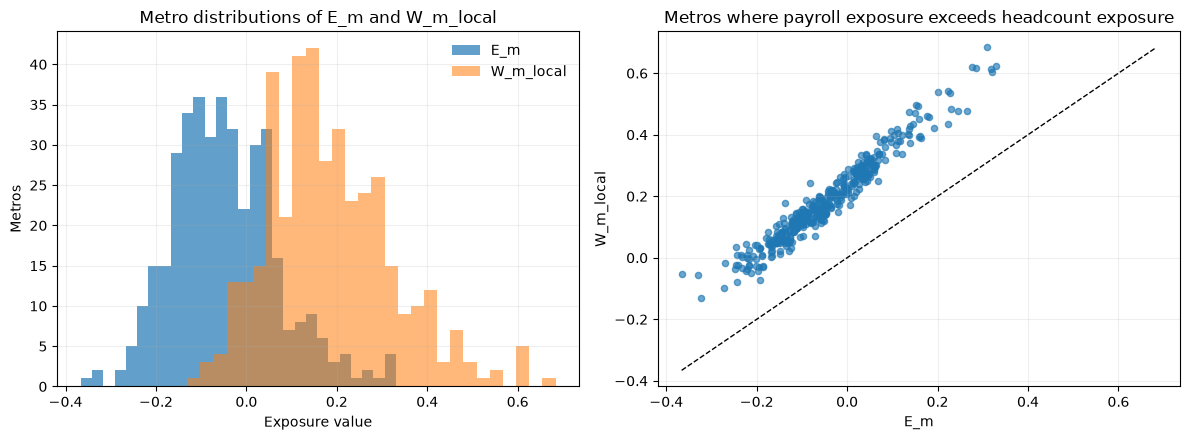

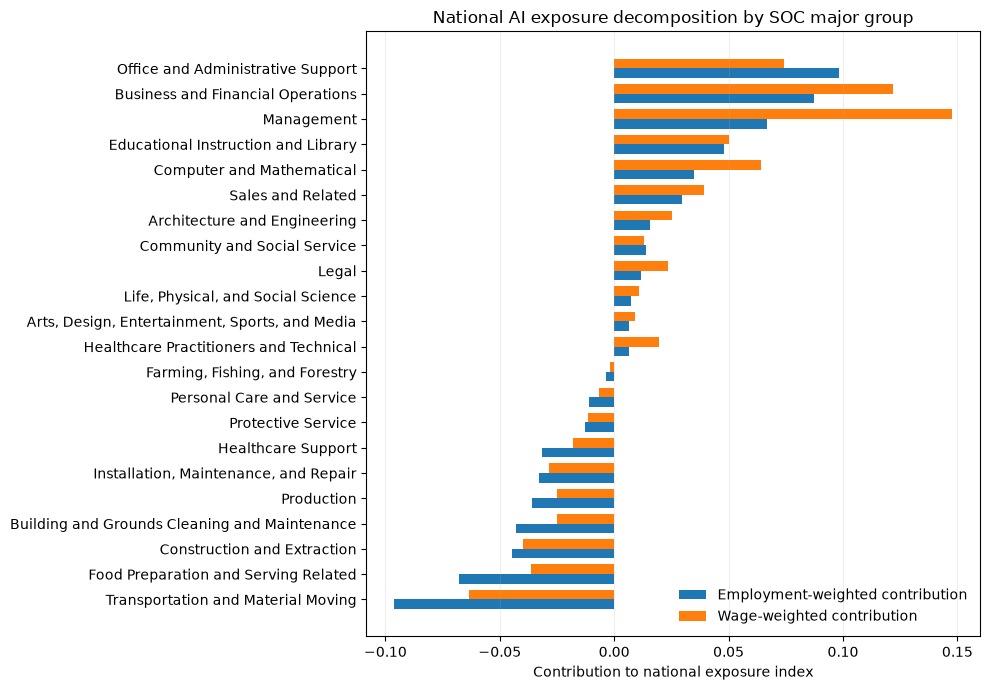

In [38]:
# Build the first baseline artifacts for the notebook: national distributions for the metro
# exposure measures, simple ranking tables, and a national SOC major-group decomposition.
import matplotlib.pyplot as plt

soc_latest_ranked = (
    soc_latest.sort_values(["e_m", "cbsa_name"], ascending=[False, True])
    .reset_index(drop=True)
)
soc_latest_ranked["e_m_rank"] = np.arange(1, len(soc_latest_ranked) + 1)
soc_latest_ranked["e_m_percentile"] = soc_latest_ranked["e_m"].rank(pct=True, method="average")
soc_latest_ranked["w_m_local_rank"] = soc_latest_ranked["w_m_local"].rank(method="first", ascending=False)
soc_latest_ranked["w_m_local_percentile"] = soc_latest_ranked["w_m_local"].rank(pct=True, method="average")
soc_latest_ranked["w_minus_e"] = soc_latest_ranked["w_m_local"] - soc_latest_ranked["e_m"]

baseline_distribution_summary = pd.DataFrame([
    {"measure": "E_m", "metric": "Metros", "value": int(len(soc_latest_ranked))},
    {"measure": "E_m", "metric": "Mean", "value": soc_latest_ranked["e_m"].mean()},
    {"measure": "E_m", "metric": "Median", "value": soc_latest_ranked["e_m"].median()},
    {"measure": "E_m", "metric": "P10", "value": soc_latest_ranked["e_m"].quantile(0.10)},
    {"measure": "E_m", "metric": "P90", "value": soc_latest_ranked["e_m"].quantile(0.90)},
    {"measure": "E_m", "metric": "Minimum", "value": soc_latest_ranked["e_m"].min()},
    {"measure": "E_m", "metric": "Maximum", "value": soc_latest_ranked["e_m"].max()},
    {"measure": "W_m_local", "metric": "Metros", "value": int(len(soc_latest_ranked))},
    {"measure": "W_m_local", "metric": "Mean", "value": soc_latest_ranked["w_m_local"].mean()},
    {"measure": "W_m_local", "metric": "Median", "value": soc_latest_ranked["w_m_local"].median()},
    {"measure": "W_m_local", "metric": "P10", "value": soc_latest_ranked["w_m_local"].quantile(0.10)},
    {"measure": "W_m_local", "metric": "P90", "value": soc_latest_ranked["w_m_local"].quantile(0.90)},
    {"measure": "W_m_local", "metric": "Minimum", "value": soc_latest_ranked["w_m_local"].min()},
    {"measure": "W_m_local", "metric": "Maximum", "value": soc_latest_ranked["w_m_local"].max()},
])

# This gap summary makes the baseline relationship explicit: exposed payroll usually runs
# higher than exposed headcount, which implies AI exposure tilts toward higher-wage work.
baseline_gap_summary = pd.DataFrame([
    {"metric": "Mean W_m_local - E_m", "value": soc_latest_ranked["w_minus_e"].mean()},
    {"metric": "Median W_m_local - E_m", "value": soc_latest_ranked["w_minus_e"].median()},
    {"metric": "Share of metros where W_m_local > E_m", "value": soc_latest_ranked["w_minus_e"].gt(0).mean()},
    {"metric": "Pearson correlation of metro measures", "value": np.corrcoef(soc_latest_ranked["e_m"], soc_latest_ranked["w_m_local"])[0, 1]},
])

top_15_exposure = soc_latest_ranked.head(15)[[
    "e_m_rank", "cbsa_name", "e_m", "w_m_local", "w_minus_e", "coverage_share", "payroll_coverage_share"
]]
bottom_15_exposure = soc_latest_ranked.tail(15).sort_values(["e_m", "cbsa_name"], ascending=[True, True])[[
    "cbsa_name", "e_m", "w_m_local", "w_minus_e", "coverage_share", "payroll_coverage_share"
]]

soc_major_group_labels = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

national_soc_detail = soc_cbsa_scored.loc[
    (soc_cbsa_scored["year"] == latest_soc_year) & soc_cbsa_scored["matched_flag"]
].copy()
national_soc_detail["soc_major_group"] = national_soc_detail["soc_code"].str.slice(0, 2)
national_soc_detail["soc_major_group_label"] = national_soc_detail["soc_major_group"].map(soc_major_group_labels).fillna("Other / Unmapped")
national_detailed_employment = soc_cbsa_scored.loc[soc_cbsa_scored["year"] == latest_soc_year, "employment"].sum()
national_matched_payroll = national_soc_detail["wage_bill"].sum()
national_soc_detail["national_employment_share"] = national_soc_detail["employment"] / national_detailed_employment
national_soc_detail["national_payroll_share"] = national_soc_detail["wage_bill"] / national_matched_payroll
national_soc_detail["employment_weighted_score_component"] = national_soc_detail["employment"] * national_soc_detail["felten_score"]
national_soc_detail["payroll_weighted_score_component"] = national_soc_detail["wage_bill"] * national_soc_detail["felten_score"]
national_soc_detail["contribution_to_national_e"] = national_soc_detail["national_employment_share"] * national_soc_detail["felten_score"]
national_soc_detail["contribution_to_national_w_local"] = national_soc_detail["national_payroll_share"] * national_soc_detail["felten_score"]

national_soc_group_decomposition = (
    national_soc_detail.groupby(["soc_major_group", "soc_major_group_label"], as_index=False)
    .agg(
        employment=("employment", "sum"),
        wage_bill=("wage_bill", "sum"),
        national_employment_share=("national_employment_share", "sum"),
        national_payroll_share=("national_payroll_share", "sum"),
        contribution_to_national_e=("contribution_to_national_e", "sum"),
        contribution_to_national_w_local=("contribution_to_national_w_local", "sum"),
        employment_weighted_score_component=("employment_weighted_score_component", "sum"),
        payroll_weighted_score_component=("payroll_weighted_score_component", "sum"),
    )
)
national_soc_group_decomposition["employment_weighted_felten_score"] = (
    national_soc_group_decomposition["employment_weighted_score_component"] / national_soc_group_decomposition["employment"]
)
national_soc_group_decomposition["payroll_weighted_felten_score"] = (
    national_soc_group_decomposition["payroll_weighted_score_component"] / national_soc_group_decomposition["wage_bill"]
)
national_soc_group_decomposition = national_soc_group_decomposition.sort_values(
    ["contribution_to_national_e", "national_employment_share"],
    ascending=[False, False],
).reset_index(drop=True)

richmond_summary = soc_latest_ranked.loc[soc_latest_ranked["cbsa_code"] == RICHMOND_CBSA_CODE, [
    "cbsa_code", "cbsa_name", "e_m_rank", "e_m_percentile", "e_m", "w_m_local", "coverage_share", "payroll_coverage_share"
]]

display(baseline_distribution_summary.style.format({"value": "{:.3f}"}))
display(baseline_gap_summary.style.format({"value": "{:.3f}"}))
display(top_15_exposure.style.format({"e_m": "{:.3f}", "w_m_local": "{:.3f}", "w_minus_e": "{:.3f}", "coverage_share": "{:.1%}", "payroll_coverage_share": "{:.1%}"}))
display(bottom_15_exposure.style.format({"e_m": "{:.3f}", "w_m_local": "{:.3f}", "w_minus_e": "{:.3f}", "coverage_share": "{:.1%}", "payroll_coverage_share": "{:.1%}"}))
display(richmond_summary.style.format({"e_m_percentile": "{:.1%}", "e_m": "{:.3f}", "w_m_local": "{:.3f}", "coverage_share": "{:.1%}", "payroll_coverage_share": "{:.1%}"}))
display(national_soc_group_decomposition[[
    "soc_major_group_label", "national_employment_share", "national_payroll_share",
    "contribution_to_national_e", "contribution_to_national_w_local",
    "employment_weighted_felten_score", "payroll_weighted_felten_score"
]].head(15).style.format({
    "national_employment_share": "{:.2%}", "national_payroll_share": "{:.2%}",
    "contribution_to_national_e": "{:.4f}", "contribution_to_national_w_local": "{:.4f}",
    "employment_weighted_felten_score": "{:.3f}", "payroll_weighted_felten_score": "{:.3f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(soc_latest_ranked["e_m"], bins=28, alpha=0.70, label="E_m")
axes[0].hist(soc_latest_ranked["w_m_local"], bins=28, alpha=0.55, label="W_m_local")
axes[0].set_title("Metro distributions of E_m and W_m_local")
axes[0].set_xlabel("Exposure value")
axes[0].set_ylabel("Metros")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

axes[1].scatter(soc_latest_ranked["e_m"], soc_latest_ranked["w_m_local"], alpha=0.65, s=20)
line_floor = min(soc_latest_ranked["e_m"].min(), soc_latest_ranked["w_m_local"].min())
line_ceiling = max(soc_latest_ranked["e_m"].max(), soc_latest_ranked["w_m_local"].max())
axes[1].plot([line_floor, line_ceiling], [line_floor, line_ceiling], color="black", linewidth=1, linestyle="--")
axes[1].set_title("Metros where payroll exposure exceeds headcount exposure")
axes[1].set_xlabel("E_m")
axes[1].set_ylabel("W_m_local")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

national_soc_group_plot = national_soc_group_decomposition.sort_values("contribution_to_national_e", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
y_positions = np.arange(len(national_soc_group_plot))
bar_height = 0.38
ax.barh(
    y_positions - bar_height / 2,
    national_soc_group_plot["contribution_to_national_e"],
    height=bar_height,
    label="Employment-weighted contribution",
)
ax.barh(
    y_positions + bar_height / 2,
    national_soc_group_plot["contribution_to_national_w_local"],
    height=bar_height,
    label="Wage-weighted contribution",
)
ax.set_yticks(y_positions)
ax.set_yticklabels(national_soc_group_plot["soc_major_group_label"])
ax.set_title("National AI exposure decomposition by SOC major group")
ax.set_xlabel("Contribution to national exposure index")
ax.legend(frameon=False)
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()

### Baseline Decomposition Notes

The contribution fields in the decomposition tables are weighted exposure contributions. In other words, they are the relevant share multiplied by the Felten score, not just raw employment or payroll weights by themselves.

In [39]:
# Show the detailed occupation decomposition directly so we can inspect which occupations carry
# the national index, then keep the grouped view for the higher-level graphical summary.
national_occupation_decomposition = (
    national_soc_detail.groupby(["soc_code", "soc_title", "soc_major_group_label"], as_index=False)
    .agg(
        employment=("employment", "sum"),
        wage_bill=("wage_bill", "sum"),
        felten_score=("felten_score", "first"),
        national_employment_share=("national_employment_share", "sum"),
        national_payroll_share=("national_payroll_share", "sum"),
        contribution_to_national_e=("contribution_to_national_e", "sum"),
        contribution_to_national_w_local=("contribution_to_national_w_local", "sum"),
    )
    .sort_values(["contribution_to_national_e", "national_employment_share"], ascending=[False, False])
    .reset_index(drop=True)
)

display(national_occupation_decomposition[[
    "soc_code", "soc_title", "soc_major_group_label", "national_employment_share",
    "national_payroll_share", "felten_score", "contribution_to_national_e",
    "contribution_to_national_w_local"
]].head(25).style.format({
    "national_employment_share": "{:.2%}", "national_payroll_share": "{:.2%}",
    "felten_score": "{:.3f}", "contribution_to_national_e": "{:.4f}",
    "contribution_to_national_w_local": "{:.4f}"
}))

,soc_code,soc_title,soc_major_group_label,national_employment_share,national_payroll_share,felten_score,contribution_to_national_e,contribution_to_national_w_local
0,43-4051,Customer Service Representatives,Office and Administrative Support,1.68%,1.13%,0.956,0.0161,0.0108
1,43-9061,"Office Clerks, General",Office and Administrative Support,1.60%,1.08%,0.989,0.0158,0.0107
2,13-2011,Accountants and Auditors,Business and Financial Operations,0.98%,1.34%,1.482,0.0145,0.0199
3,15-1252,Software Developers,Computer and Mathematical,1.11%,2.39%,1.201,0.0133,0.0287
4,11-1021,General and Operations Managers,Management,2.26%,4.48%,0.575,0.0130,0.0258
5,43-6014,"Secretaries and Administrative Assistants, Except Legal, Medical, and Executive",Office and Administrative Support,1.11%,0.79%,1.099,0.0122,0.0086
6,41-3091,"Sales Representatives of Services, Except Advertising, Insurance, Financial Services, and Travel",Sales and Related,0.83%,0.98%,1.303,0.0108,0.0127
7,43-1011,First-Line Supervisors of Office and Administrative Support Workers,Office and Administrative Support,0.96%,1.02%,1.039,0.0100,0.0106
8,43-3031,"Bookkeeping, Accounting, and Auditing Clerks",Office and Administrative Support,0.87%,0.68%,1.040,0.0091,0.0071
9,13-1082,Project Management Specialists,Business and Financial Operations,0.72%,1.15%,1.233,0.0088,0.0142


,naics_code,naics_title,national_employment_share,felten_score,contribution_to_national_naics_exposure
0,7225,Restaurants,9.57%,-1.172,-0.1121
1,6241,Individual and family services,2.97%,1.163,0.0345
2,6221,General medical and surgical hospitals,2.75%,0.527,0.0145
3,6211,Offices of physicians,2.50%,1.010,0.0252
4,5613,Employment services,2.47%,-0.723,-0.0179
5,4451,Grocery stores,2.41%,-0.407,-0.0098
6,2382,Building equipment contractors,2.22%,-0.832,-0.0184
7,5511,Management of companies and enterprises,2.13%,1.699,0.0361
8,5617,Services to buildings and dwellings,1.98%,-1.999,-0.0396
9,5415,Computer systems design and related services,1.83%,1.860,0.0341


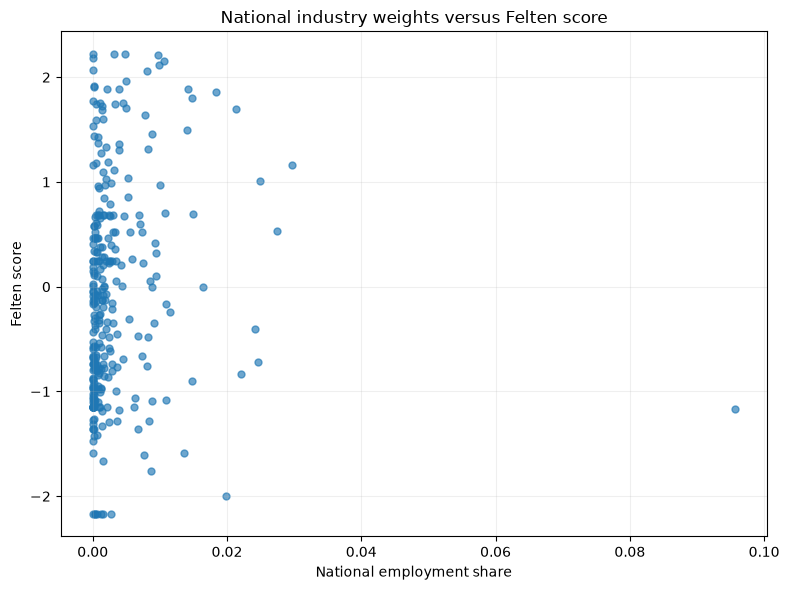

In [40]:
# Pair the occupation decomposition with a national industry-weight view. This makes it easier
# to spot industries that are small in total employment but unusually high or low on the score.
national_naics_detail = naics_cbsa_scored.loc[
    (naics_cbsa_scored["year"] == latest_naics_year) & naics_cbsa_scored["matched_flag"]
].copy()
national_naics_total_employment = naics_cbsa_scored.loc[naics_cbsa_scored["year"] == latest_naics_year, "employment"].sum()
national_naics_detail["national_employment_share"] = national_naics_detail["employment"] / national_naics_total_employment
national_naics_detail["contribution_to_national_naics_exposure"] = national_naics_detail["national_employment_share"] * national_naics_detail["felten_score"]

national_naics_industry_decomposition = (
    national_naics_detail.groupby(["naics_code", "naics_title"], as_index=False)
    .agg(
        employment=("employment", "sum"),
        felten_score=("felten_score", "first"),
        national_employment_share=("national_employment_share", "sum"),
        contribution_to_national_naics_exposure=("contribution_to_national_naics_exposure", "sum"),
    )
    .sort_values(["national_employment_share", "contribution_to_national_naics_exposure"], ascending=[False, False])
    .reset_index(drop=True)
)

display(national_naics_industry_decomposition[[
    "naics_code", "naics_title", "national_employment_share", "felten_score",
    "contribution_to_national_naics_exposure"
]].head(25).style.format({
    "national_employment_share": "{:.2%}", "felten_score": "{:.3f}",
    "contribution_to_national_naics_exposure": "{:.4f}"
}))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    national_naics_industry_decomposition["national_employment_share"],
    national_naics_industry_decomposition["felten_score"],
    s=25,
    alpha=0.65,
)
ax.set_title("National industry weights versus Felten score")
ax.set_xlabel("National employment share")
ax.set_ylabel("Felten score")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. H1 Wage-Weighted Vs Employment-Weighted Exposure

H1 asks whether the metro ranking changes meaningfully when we weight exposure by the local wage bill instead of job counts. We use the existing metro-level SOC table, keep `W_m_local` as the primary wage-weighted measure, and leave the detailed-SOC coverage denominator unchanged.

In [41]:
# Start H1 from the metro-level SOC exposure table already built above. This cell only builds
# the shared comparison objects; the displays live in smaller cells below.
import matplotlib.pyplot as plt

h1_comparison = soc_latest[[
    "cbsa_code", "cbsa_name", "e_m", "w_m_local", "coverage_share", "payroll_coverage_share",
    "detailed_share_of_total_oe_ws", "matched_employment", "cbsa_detailed_employment",
    "matched_payroll", "cbsa_total_payroll"
]].dropna(subset=["e_m", "w_m_local"]).copy()

h1_comparison["e_m_rank"] = h1_comparison["e_m"].rank(method="first", ascending=False)
h1_comparison["w_m_local_rank"] = h1_comparison["w_m_local"].rank(method="first", ascending=False)
h1_comparison["e_m_percentile"] = h1_comparison["e_m"].rank(pct=True, method="average")
h1_comparison["w_m_local_percentile"] = h1_comparison["w_m_local"].rank(pct=True, method="average")
h1_comparison["rank_shift"] = h1_comparison["e_m_rank"] - h1_comparison["w_m_local_rank"]
h1_comparison["absolute_rank_shift"] = h1_comparison["rank_shift"].abs()

h1_ranked_e_m = h1_comparison.sort_values(["e_m_rank", "cbsa_name"]).reset_index(drop=True)
h1_ranked_w_m_local = h1_comparison.sort_values(["w_m_local_rank", "cbsa_name"]).reset_index(drop=True)

# Spearman is just the Pearson correlation of the rank vectors, so we can compute it directly
# without adding a SciPy dependency to the notebook environment.
h1_spearman = np.corrcoef(h1_comparison["e_m_rank"], h1_comparison["w_m_local_rank"])[0, 1]
h1_mean_absolute_rank_shift = h1_comparison["absolute_rank_shift"].mean()

h1_metrics = pd.DataFrame([
    {"metric": "Metros in H1 comparison", "value": len(h1_comparison)},
    {"metric": "Spearman correlation of ranks", "value": h1_spearman},
    {"metric": "Mean absolute rank shift", "value": h1_mean_absolute_rank_shift},
    {"metric": "Median absolute rank shift", "value": h1_comparison["absolute_rank_shift"].median()},
])

h1_top_risers = h1_comparison.sort_values(
    ["rank_shift", "absolute_rank_shift", "cbsa_name"],
    ascending=[False, False, True],
).head(20)[[
    "cbsa_name", "e_m", "w_m_local", "e_m_rank", "w_m_local_rank", "rank_shift",
    "absolute_rank_shift", "e_m_percentile", "w_m_local_percentile", "coverage_share",
    "payroll_coverage_share", "detailed_share_of_total_oe_ws"
]]

h1_top_fallers = h1_comparison.sort_values(
    ["rank_shift", "absolute_rank_shift", "cbsa_name"],
    ascending=[True, False, True],
).head(20)[[
    "cbsa_name", "e_m", "w_m_local", "e_m_rank", "w_m_local_rank", "rank_shift",
    "absolute_rank_shift", "e_m_percentile", "w_m_local_percentile", "coverage_share",
    "payroll_coverage_share", "detailed_share_of_total_oe_ws"
]]

# The mover QA checks whether large rank changes are concentrated in low-coverage metros.
h1_mover_sample = pd.concat([h1_top_risers, h1_top_fallers], ignore_index=True)
h1_top_decile_cutoff = h1_comparison["absolute_rank_shift"].quantile(0.90)
h1_top_decile_movers = h1_comparison.loc[h1_comparison["absolute_rank_shift"] >= h1_top_decile_cutoff].copy()

h1_coverage_qa = pd.DataFrame([
    {
        "group": "All metros",
        "metros": len(h1_comparison),
        "mean_coverage_share": h1_comparison["coverage_share"].mean(),
        "median_coverage_share": h1_comparison["coverage_share"].median(),
        "mean_payroll_coverage_share": h1_comparison["payroll_coverage_share"].mean(),
        "share_below_90pct_coverage": h1_comparison["coverage_share"].lt(0.90).mean(),
        "share_below_90pct_payroll_coverage": h1_comparison["payroll_coverage_share"].lt(0.90).mean(),
        "mean_absolute_rank_shift": h1_comparison["absolute_rank_shift"].mean(),
    },
    {
        "group": "Top/bottom 20 movers",
        "metros": len(h1_mover_sample),
        "mean_coverage_share": h1_mover_sample["coverage_share"].mean(),
        "median_coverage_share": h1_mover_sample["coverage_share"].median(),
        "mean_payroll_coverage_share": h1_mover_sample["payroll_coverage_share"].mean(),
        "share_below_90pct_coverage": h1_mover_sample["coverage_share"].lt(0.90).mean(),
        "share_below_90pct_payroll_coverage": h1_mover_sample["payroll_coverage_share"].lt(0.90).mean(),
        "mean_absolute_rank_shift": h1_mover_sample["absolute_rank_shift"].mean(),
    },
    {
        "group": "Top decile absolute movers",
        "metros": len(h1_top_decile_movers),
        "mean_coverage_share": h1_top_decile_movers["coverage_share"].mean(),
        "median_coverage_share": h1_top_decile_movers["coverage_share"].median(),
        "mean_payroll_coverage_share": h1_top_decile_movers["payroll_coverage_share"].mean(),
        "share_below_90pct_coverage": h1_top_decile_movers["coverage_share"].lt(0.90).mean(),
        "share_below_90pct_payroll_coverage": h1_top_decile_movers["payroll_coverage_share"].lt(0.90).mean(),
        "mean_absolute_rank_shift": h1_top_decile_movers["absolute_rank_shift"].mean(),
    },
])

,metric,value
0,Metros in H1 comparison,393.000
1,Spearman correlation of ranks,0.973
2,Mean absolute rank shift,19.751
3,Median absolute rank shift,16.000


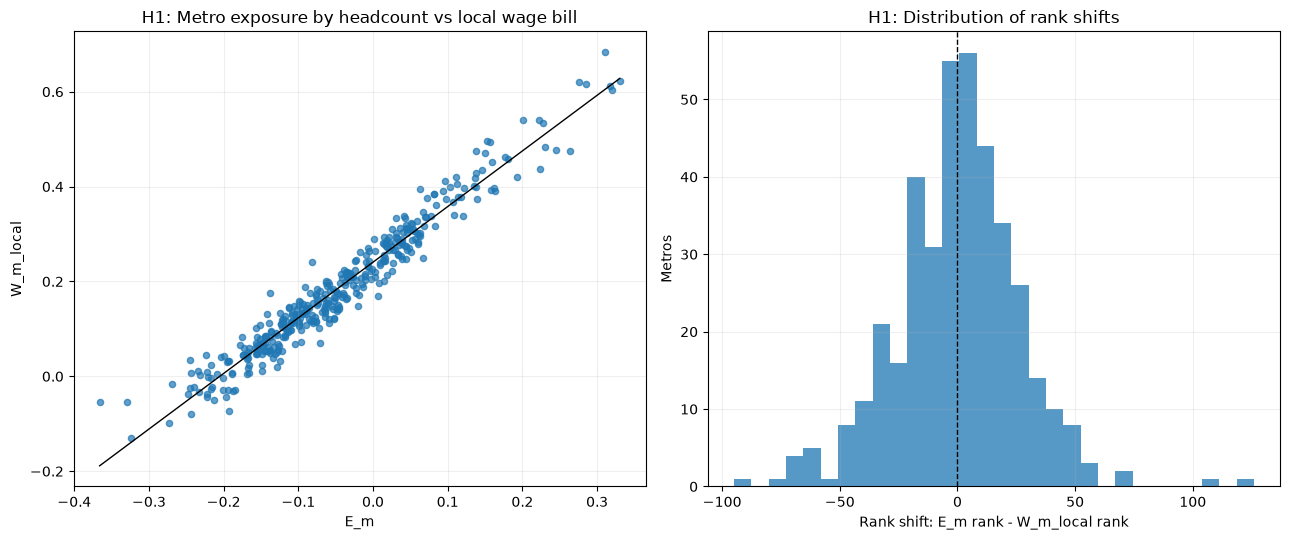

In [42]:
# Put the headline numbers and the two key visuals up front so the reader gets the H1 answer
# before diving into metro-level detail.
display(h1_metrics.style.format({"value": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(h1_comparison["e_m"], h1_comparison["w_m_local"], alpha=0.7, s=20)
regression_coefficients = np.polyfit(h1_comparison["e_m"], h1_comparison["w_m_local"], 1)
x_grid = np.linspace(h1_comparison["e_m"].min(), h1_comparison["e_m"].max(), 200)
axes[0].plot(x_grid, regression_coefficients[0] * x_grid + regression_coefficients[1], color="black", linewidth=1)
axes[0].set_title("H1: Metro exposure by headcount vs local wage bill")
axes[0].set_xlabel("E_m")
axes[0].set_ylabel("W_m_local")
axes[0].grid(alpha=0.2)

axes[1].hist(h1_comparison["rank_shift"], bins=30, alpha=0.75)
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("H1: Distribution of rank shifts")
axes[1].set_xlabel("Rank shift: E_m rank - W_m_local rank")
axes[1].set_ylabel("Metros")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [43]:
# Show the metros that move most once we switch from headcount to payroll weighting, then
# follow immediately with the coverage QA that tells us whether those movers look credible.
display(h1_top_risers.style.format({
    "e_m": "{:.3f}", "w_m_local": "{:.3f}", "e_m_percentile": "{:.1%}",
    "w_m_local_percentile": "{:.1%}", "coverage_share": "{:.1%}",
    "payroll_coverage_share": "{:.1%}", "detailed_share_of_total_oe_ws": "{:.1%}"
}))
display(h1_top_fallers.style.format({
    "e_m": "{:.3f}", "w_m_local": "{:.3f}", "e_m_percentile": "{:.1%}",
    "w_m_local_percentile": "{:.1%}", "coverage_share": "{:.1%}",
    "payroll_coverage_share": "{:.1%}", "detailed_share_of_total_oe_ws": "{:.1%}"
}))
display(h1_coverage_qa.style.format({
    "mean_coverage_share": "{:.1%}", "median_coverage_share": "{:.1%}",
    "mean_payroll_coverage_share": "{:.1%}", "share_below_90pct_coverage": "{:.1%}",
    "share_below_90pct_payroll_coverage": "{:.1%}", "mean_absolute_rank_shift": "{:.1f}"
}))

,cbsa_name,e_m,w_m_local,e_m_rank,w_m_local_rank,rank_shift,absolute_rank_shift,e_m_percentile,w_m_local_percentile,coverage_share,payroll_coverage_share,detailed_share_of_total_oe_ws
232,"Midland, TX",-0.138,0.176,308.000000,182.000000,126.000000,126.000000,21.9%,53.9%,99.8%,99.9%,93.4%
322,"Santa Maria-Santa Barbara, CA",-0.082,0.242,231.000000,126.000000,105.000000,105.000000,41.5%,68.2%,99.8%,99.8%,96.5%
126,"Fresno, CA",-0.142,0.131,314.000000,245.000000,69.000000,69.000000,20.4%,37.9%,99.7%,99.7%,98.5%
141,"Greensboro-High Point, NC",-0.091,0.189,242.000000,174.000000,68.000000,68.000000,38.7%,56.0%,99.6%,99.8%,97.9%
136,"Grand Rapids-Wyoming-Kentwood, MI",-0.112,0.146,275.000000,218.000000,57.000000,57.000000,30.3%,44.8%,99.8%,99.8%,97.7%
227,"Memphis, TN-MS-AR",-0.124,0.133,293.000000,237.000000,56.000000,56.000000,25.7%,39.9%,99.5%,99.6%,97.6%
8,"Allentown-Bethlehem-Easton, PA-NJ",-0.099,0.159,258.000000,203.000000,55.000000,55.000000,34.6%,48.6%,99.8%,99.9%,98.5%
104,"El Centro, CA",-0.175,0.083,353.000000,301.000000,52.000000,52.000000,10.4%,23.7%,99.9%,99.9%,88.4%
155,"Hilton Head Island-Bluffton-Port Royal, SC",-0.112,0.144,274.000000,222.000000,52.000000,52.000000,30.5%,43.8%,99.9%,100.0%,94.8%
382,"Wildwood-The Villages, FL",-0.156,0.102,336.000000,284.000000,52.000000,52.000000,14.8%,28.0%,100.0%,100.0%,85.5%


,cbsa_name,e_m,w_m_local,e_m_rank,w_m_local_rank,rank_shift,absolute_rank_shift,e_m_percentile,w_m_local_percentile,coverage_share,payroll_coverage_share,detailed_share_of_total_oe_ws
144,"Guayama, PR",-0.070,0.070,215.000000,310.000000,-95.000000,95.000000,45.5%,21.4%,100.0%,100.0%,68.7%
57,"Cape Girardeau, MO-IL",-0.058,0.112,196.000000,274.000000,-78.000000,78.000000,50.4%,30.5%,99.9%,99.9%,85.0%
113,"Fairbanks-College, AK",-0.021,0.147,147.000000,217.000000,-70.000000,70.000000,62.8%,45.0%,99.8%,99.9%,79.1%
102,"Eagle Pass, TX",0.006,0.170,124.000000,192.000000,-68.000000,68.000000,68.7%,51.4%,100.0%,100.0%,58.3%
138,"Great Falls, MT",-0.052,0.121,189.000000,256.000000,-67.000000,67.000000,52.2%,35.1%,99.6%,99.7%,85.5%
226,"Medford, OR",-0.072,0.102,217.000000,283.000000,-66.000000,66.000000,45.0%,28.2%,99.5%,99.6%,93.9%
173,"Jefferson City, MO",0.067,0.249,52.000000,117.000000,-65.000000,65.000000,87.0%,70.5%,99.9%,99.9%,89.2%
375,"Watertown-Fort Drum, NY",-0.052,0.122,190.000000,253.000000,-63.000000,63.000000,51.9%,35.9%,99.6%,99.6%,86.9%
235,"Minot, ND",-0.128,0.020,297.000000,358.000000,-61.000000,61.000000,24.7%,9.2%,100.0%,100.0%,84.4%
205,"Lewiston-Auburn, ME",-0.097,0.072,247.000000,307.000000,-60.000000,60.000000,37.4%,22.1%,100.0%,100.0%,88.4%


,group,metros,mean_coverage_share,median_coverage_share,mean_payroll_coverage_share,share_below_90pct_coverage,share_below_90pct_payroll_coverage,mean_absolute_rank_shift
0,All metros,393,99.8%,99.8%,99.8%,0.0%,0.0%,19.8
1,Top/bottom 20 movers,40,99.8%,99.9%,99.9%,0.0%,0.0%,58.1
2,Top decile absolute movers,41,99.8%,99.9%,99.9%,0.0%,0.0%,57.9


In [44]:
# Keep the raw top-ranked lists at the end of H1. They are useful reference tables, but they
# are less important than the metrics, plots, movers, and coverage diagnostics above.
display(h1_ranked_e_m.head(20).style.format({
    "e_m": "{:.3f}", "w_m_local": "{:.3f}", "e_m_percentile": "{:.1%}",
    "w_m_local_percentile": "{:.1%}", "coverage_share": "{:.1%}",
    "payroll_coverage_share": "{:.1%}", "detailed_share_of_total_oe_ws": "{:.1%}"
}))
display(h1_ranked_w_m_local.head(20).style.format({
    "e_m": "{:.3f}", "w_m_local": "{:.3f}", "e_m_percentile": "{:.1%}",
    "w_m_local_percentile": "{:.1%}", "coverage_share": "{:.1%}",
    "payroll_coverage_share": "{:.1%}", "detailed_share_of_total_oe_ws": "{:.1%}"
}))

,cbsa_code,cbsa_name,e_m,w_m_local,coverage_share,payroll_coverage_share,detailed_share_of_total_oe_ws,matched_employment,cbsa_detailed_employment,matched_payroll,cbsa_total_payroll,e_m_rank,w_m_local_rank,e_m_percentile,w_m_local_percentile,rank_shift,absolute_rank_shift
0,30500,"Lexington Park, MD",0.330,0.623,99.8%,99.8%,92.0%,64830.000000,64980.000000,5359482500.000000,5371086600.000000,1.000000,2.000000,100.0%,99.7%,-1.000000,1.000000
1,14500,"Boulder, CO",0.320,0.603,99.3%,99.5%,94.3%,180010.000000,181330.000000,15692359600.000000,15767379300.000000,2.000000,6.000000,99.7%,98.7%,-4.000000,4.000000
2,45940,"Trenton-Princeton, NJ",0.317,0.613,99.5%,99.5%,92.4%,220630.000000,221850.000000,18260040100.000000,18355281600.000000,3.000000,5.000000,99.5%,99.0%,-2.000000,2.000000
3,41940,"San Jose-Sunnyvale-Santa Clara, CA",0.310,0.684,99.6%,99.8%,98.5%,1114020.000000,1118290.000000,131740776600.000000,132067177100.000000,4.000000,1.000000,99.2%,100.0%,3.000000,3.000000
4,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.285,0.616,99.4%,99.4%,98.4%,3066720.000000,3084640.000000,277913309500.000000,279724598700.000000,5.000000,4.000000,99.0%,99.2%,1.000000,1.000000
5,20500,"Durham-Chapel Hill, NC",0.276,0.620,99.7%,99.6%,87.2%,298880.000000,299900.000000,22517700000.000000,22606853800.000000,6.000000,3.000000,98.7%,99.5%,3.000000,3.000000
6,11460,"Ann Arbor, MI",0.264,0.476,99.7%,99.7%,95.1%,208390.000000,209020.000000,14557704400.000000,14595062400.000000,7.000000,14.000000,98.5%,96.7%,-7.000000,7.000000
7,45220,"Tallahassee, FL",0.245,0.477,99.7%,99.8%,93.9%,174370.000000,174840.000000,10156182900.000000,10178471200.000000,8.000000,13.000000,98.2%,96.9%,-5.000000,5.000000
8,27060,"Ithaca, NY",0.230,0.483,99.6%,99.5%,82.4%,39360.000000,39530.000000,2864252600.000000,2878008200.000000,9.000000,12.000000,98.0%,97.2%,-3.000000,3.000000
9,14460,"Boston-Cambridge-Newton, MA-NH",0.227,0.534,99.8%,99.8%,98.2%,2648730.000000,2655240.000000,232418320300.000000,232798715400.000000,10.000000,9.000000,97.7%,98.0%,1.000000,1.000000


,cbsa_code,cbsa_name,e_m,w_m_local,coverage_share,payroll_coverage_share,detailed_share_of_total_oe_ws,matched_employment,cbsa_detailed_employment,matched_payroll,cbsa_total_payroll,e_m_rank,w_m_local_rank,e_m_percentile,w_m_local_percentile,rank_shift,absolute_rank_shift
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",0.310,0.684,99.6%,99.8%,98.5%,1114020.000000,1118290.000000,131740776600.000000,132067177100.000000,4.000000,1.000000,99.2%,100.0%,3.000000,3.000000
1,30500,"Lexington Park, MD",0.330,0.623,99.8%,99.8%,92.0%,64830.000000,64980.000000,5359482500.000000,5371086600.000000,1.000000,2.000000,100.0%,99.7%,-1.000000,1.000000
2,20500,"Durham-Chapel Hill, NC",0.276,0.620,99.7%,99.6%,87.2%,298880.000000,299900.000000,22517700000.000000,22606853800.000000,6.000000,3.000000,98.7%,99.5%,3.000000,3.000000
3,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.285,0.616,99.4%,99.4%,98.4%,3066720.000000,3084640.000000,277913309500.000000,279724598700.000000,5.000000,4.000000,99.0%,99.2%,1.000000,1.000000
4,45940,"Trenton-Princeton, NJ",0.317,0.613,99.5%,99.5%,92.4%,220630.000000,221850.000000,18260040100.000000,18355281600.000000,3.000000,5.000000,99.5%,99.0%,-2.000000,2.000000
5,14500,"Boulder, CO",0.320,0.603,99.3%,99.5%,94.3%,180010.000000,181330.000000,15692359600.000000,15767379300.000000,2.000000,6.000000,99.7%,98.7%,-4.000000,4.000000
6,12420,"Austin-Round Rock-San Marcos, TX",0.223,0.541,99.7%,99.8%,97.9%,1262890.000000,1266690.000000,94212174000.000000,94415871400.000000,12.000000,7.000000,97.2%,98.5%,5.000000,5.000000
7,41860,"San Francisco-Oakland-Fremont, CA",0.201,0.540,99.5%,99.6%,98.9%,2334440.000000,2346620.000000,232371658800.000000,233245924500.000000,13.000000,8.000000,96.9%,98.2%,5.000000,5.000000
8,14460,"Boston-Cambridge-Newton, MA-NH",0.227,0.534,99.8%,99.8%,98.2%,2648730.000000,2655240.000000,232418320300.000000,232798715400.000000,10.000000,9.000000,97.7%,98.0%,1.000000,1.000000
9,26620,"Huntsville, AL",0.153,0.496,100.0%,100.0%,94.6%,252130.000000,252130.000000,17916867500.000000,17916867500.000000,22.000000,10.000000,94.7%,97.7%,12.000000,12.000000


## Next Analysis Blocks

The notebook is now reset to the point where we can build the analysis itself without carrying the old crosswalk-review baggage.

Natural next sections from `analysis_program.md`:

- H1: compare `E_m` and `W_m` and measure the rank shifts.
- H2: compare exposure to attainment and then add industry mix.
- H3: decide whether concentration is a real hypothesis or just a descriptive cut.

Because the source-year mix is explicit in `metro_analysis_base`, we can now build each of those sections in a cleaner way.